<a href="https://colab.research.google.com/github/lubabasadiyanp/sentimental-analysis-of-product-review/blob/preprocessing-and-eda/Preprocessing%2C_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving amazon_sales_dataset.csv to amazon_sales_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv('amazon_sales_dataset.csv')
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [ ]:
df.describe

<bound method NDFrame.describe of        order_id  order_date  product_id product_category   price  \
0             1  2022-04-13        2637            Books  128.75   
1             2  2023-03-12        2300          Fashion  302.60   
2             3  2022-09-28        3670           Sports  495.80   
3             4  2022-04-17        2522            Books  371.95   
4             5  2022-03-13        1717           Beauty  201.68   
...         ...         ...         ...              ...     ...   
49995     49996  2022-09-03        1433           Beauty   26.99   
49996     49997  2022-07-03        1428           Beauty  294.23   
49997     49998  2023-02-17        4651      Electronics  352.11   
49998     49999  2022-09-30        4371           Beauty  307.54   
49999     50000  2023-06-29        2944   Home & Kitchen  253.44   

       discount_percent  quantity_sold customer_region payment_method  rating  \
0                    10              4   North America            UPI     3.5   
1                    20              5            Asia    Credit Card     3.7   
2                    20              2          Europe            UPI     4.4   
3                    15              4     Middle East            UPI     5.0   
4                     0              4     Middle East            UPI     4.6   
...                 ...            ...             ...            ...     ...   
49995                 0              5     Middle East    Credit Card     2.4   
49996                10              5            Asia    Credit Card     3.1   
49997                30              4            Asia     Debit Card     3.1   
49998                 5              1     Middle East            UPI     1.8   
49999                30              1          Europe     Debit Card     2.1   

       review_count  discounted_price  total_revenue  
0               443            115.88         463.52  
1               475            242.08        1210.40  
2               183            396.64         793.28  
3               212            316.16        1264.64  
4               308            201.68         806.72  
...             ...               ...            ...  
49995           386             26.99         134.95  
49996             8            264.81        1324.05  
49997           104            246.48         985.92  
49998           316            292.16         292.16  
49999           464            177.41         177.41  

[50000 rows x 13 columns]>

In [ ]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

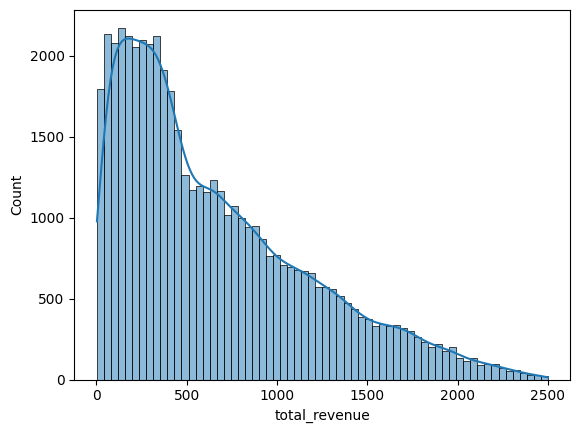

In [ ]:
sns.histplot(df['total_revenue'], kde=True)
plt.show()

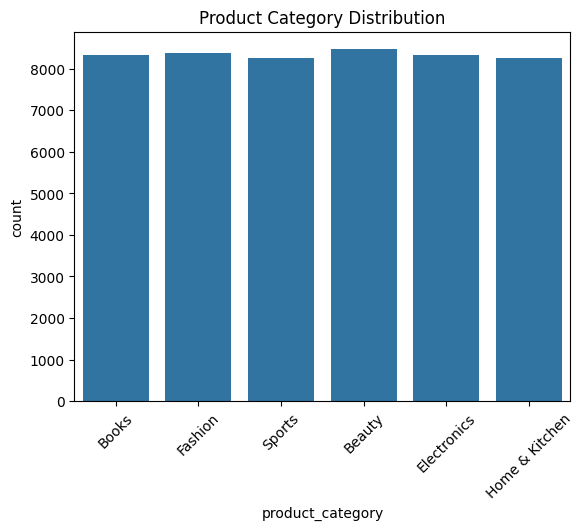

In [ ]:
sns.countplot(x='product_category', data=df)
plt.xticks(rotation=45)
plt.title("Product Category Distribution")
plt.show()

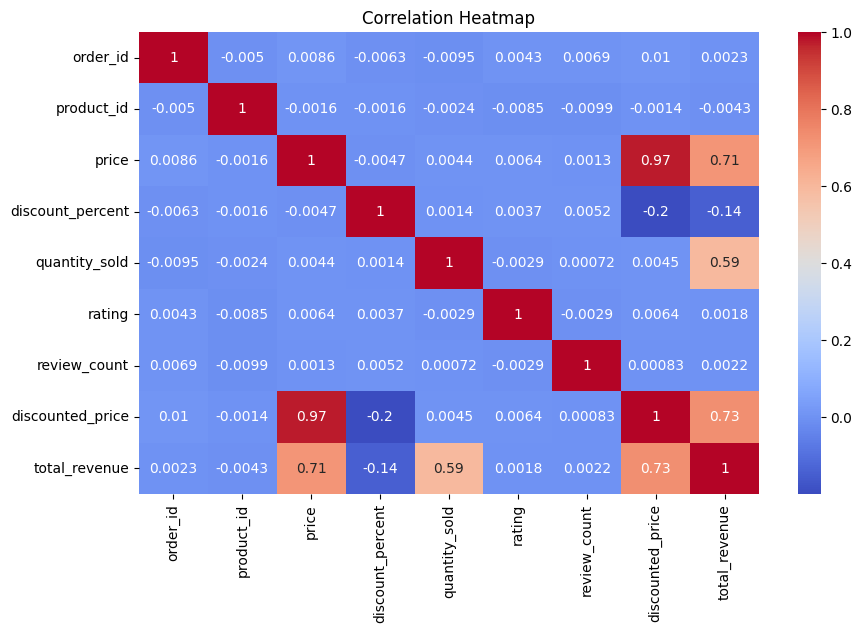

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

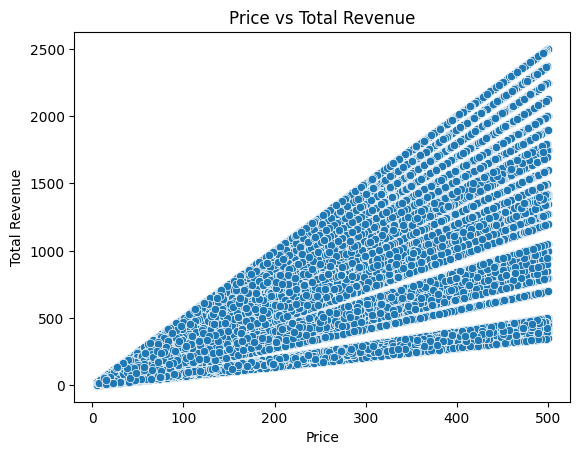

In [ ]:
sns.scatterplot(x='price', y='total_revenue', data=df)
plt.title("Price vs Total Revenue")
plt.xlabel("Price")
plt.ylabel("Total Revenue")
plt.show()

**3.Data Cleaning, Preprocessing**

In [ ]:
# Convert order_date to datetime format
df['order_date'] = pd.to_datetime(df['order_date'])

# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Optional: Drop duplicates if any are found
# df.drop_duplicates(inplace=True)

Missing values in each column:
 order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

Number of duplicate rows: 0


In [ ]:
# 1. Convert order_date to actual datetime objects
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Create useful new columns for EDA
df['month'] = df['order_date'].dt.month_name()
df['day_of_week'] = df['order_date'].dt.day_name()
df['year'] = df['order_date'].dt.year

print("Data types after conversion:")
print(df.dtypes[['order_date', 'month', 'year']])

Data types after conversion:
order_date    datetime64[ns]
month                 object
year                   int32
dtype: object





*   order_date (datetime64[ns]): This is no longer just "text." You can now easily calculate things like "Days between orders" or "Sales per weekday."
*  month (object): This contains the names (January, February, etc.). It’s perfect for grouping your data to see which month had the highest sales.


*   year (int32): This is a number. It allows you to compare performance if your data covers more than one year (e.g., 2022 vs 2023).




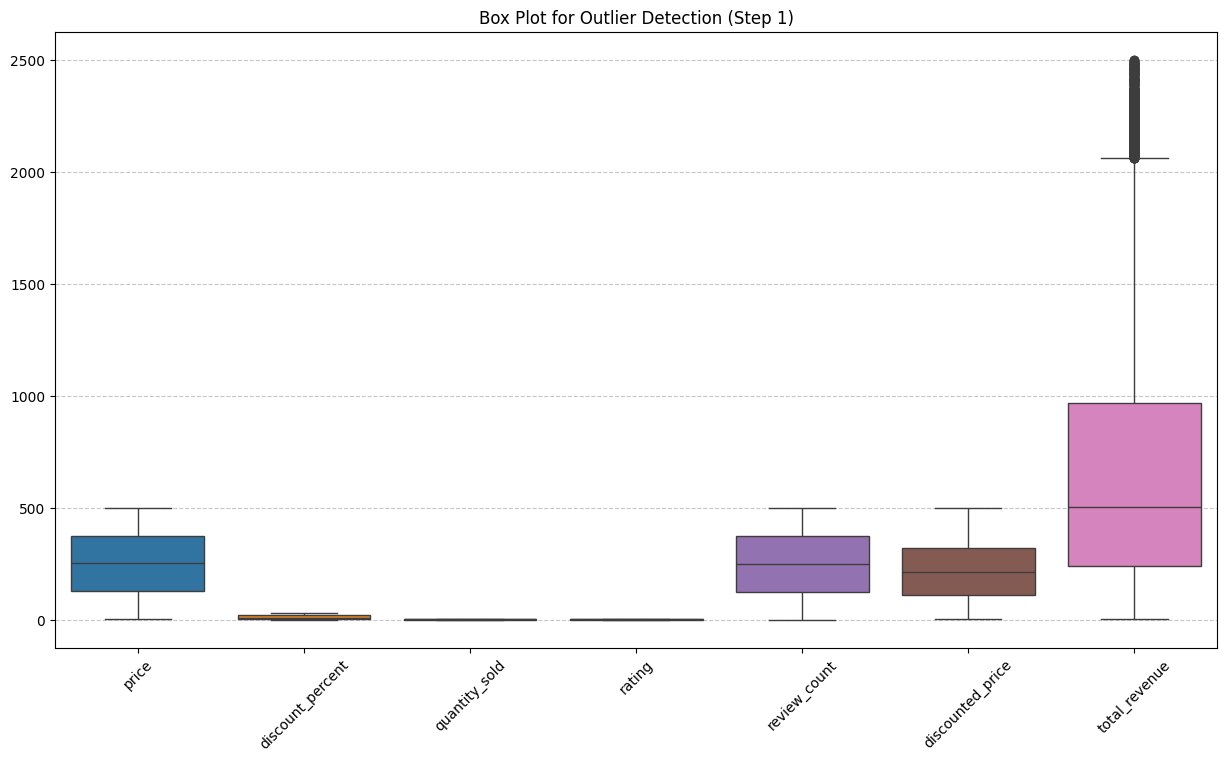

Column 'price' has 0 outliers.
Column 'discount_percent' has 0 outliers.
Column 'quantity_sold' has 0 outliers.
Column 'rating' has 0 outliers.
Column 'review_count' has 0 outliers.
Column 'discounted_price' has 0 outliers.
Column 'total_revenue' has 752 outliers.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting numerical columns that might have outliers
numerical_cols = ['price', 'discount_percent', 'quantity_sold', 'rating', 'review_count', 'discounted_price', 'total_revenue']

# Create a box plot for all numerical columns
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numerical_cols])
plt.title('Box Plot for Outlier Detection (Step 1)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Precise Calculation: Count of outliers using IQR
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Column '{col}' has {len(outliers)} outliers.")

In [ ]:
# We will cap outliers at the 1st and 99th percentiles
# This treats the extreme values but KEEPS the data (Real-life approach)

cols_to_treat = ['price', 'review_count', 'discounted_price', 'total_revenue']

for col in cols_to_treat:
    # Calculate the 1st and 99th percentiles
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)

    # Apply capping
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

print("Treatment Complete: Outliers capped at 1st and 99th percentiles.")

Treatment Complete: Outliers capped at 1st and 99th percentiles.


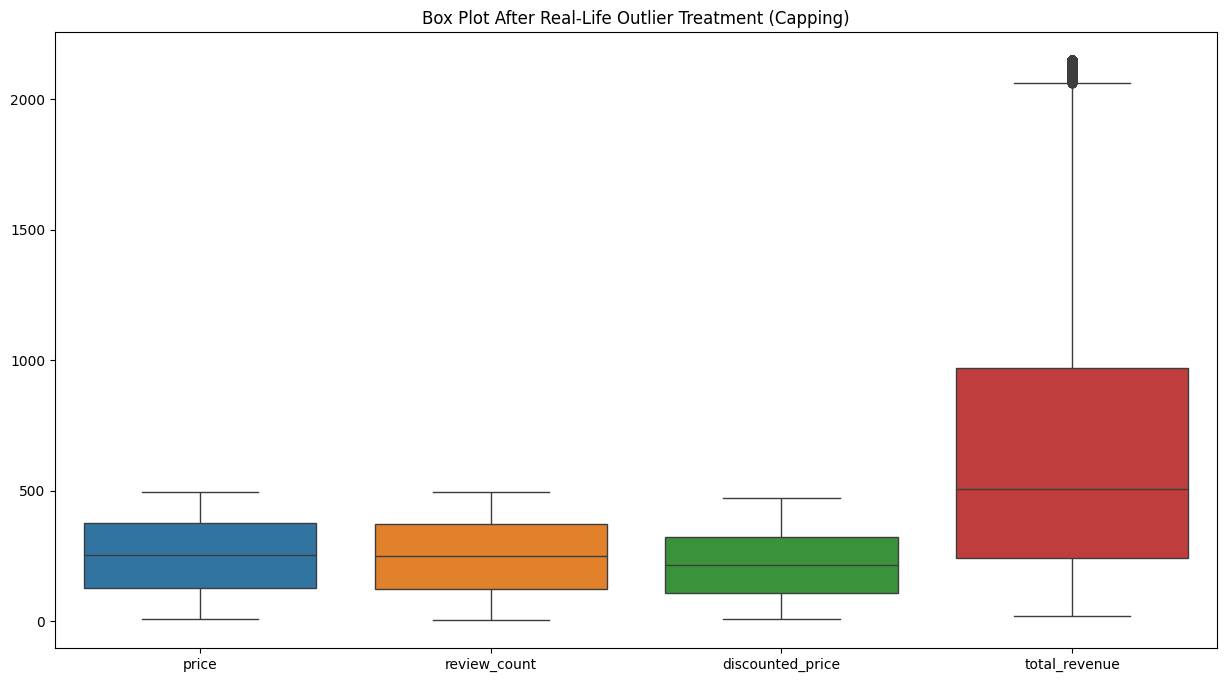

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[cols_to_treat])
plt.title('Box Plot After Real-Life Outlier Treatment (Capping)')
plt.show()

In [ ]:
print(f"Skewness of Revenue: {df['total_revenue'].skew()}")
# If skewness > 1, the data is highly skewed.

Skewness of Revenue: 0.9396148976507038


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- TASK 3: Outlier Treatment (Capping) ---
# We use the 1st and 99th percentile to keep the data realistic
cols_to_treat = ['price', 'review_count', 'discounted_price', 'total_revenue']

for col in cols_to_treat:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

print("Outliers capped at 1st and 99th percentiles.")

# --- TASK 4: Feature Scaling (Standardization) ---
# This scales numerical data so they have a mean of 0 and standard deviation of 1
scaler = StandardScaler()

# We scale the treated columns + quantity sold
cols_to_scale = ['price', 'discount_percent', 'quantity_sold', 'total_revenue', 'review_count']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("Data Scaling (Standardization) complete.")

# Final check of your work
df.head()

Outliers capped at 1st and 99th percentiles.
Data Scaling (Standardization) complete.


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,month,day_of_week,year
0,1,2022-04-13,2637,Books,-0.865804,-0.339137,0.706945,North America,UPI,3.5,1.343245,115.88,-0.368767,April,Wednesday,2022
1,2,2023-03-12,2300,Fashion,0.350451,0.676030,1.413465,Asia,Credit Card,3.7,1.565188,242.08,1.061395,March,Sunday,2023
2,3,2022-09-28,3670,Sports,1.696553,0.676030,-0.706097,Europe,UPI,4.4,-0.460047,396.64,0.262674,September,Wednesday,2022
3,4,2022-04-17,2522,Books,0.835624,0.168447,0.706945,Middle East,UPI,5.0,-0.258910,316.16,1.165256,April,Sunday,2022
4,5,2022-03-13,1717,Beauty,-0.355586,-1.354304,0.706945,Middle East,UPI,4.6,0.406920,201.68,0.288409,March,Sunday,2022


**4.Exploratory Data Analysis (EDA).**

1. Univariate Analysis (Checking Distributions)


Since we just scaled our data, we should check how the variables look now. This helps to  understand the "shape" of data.

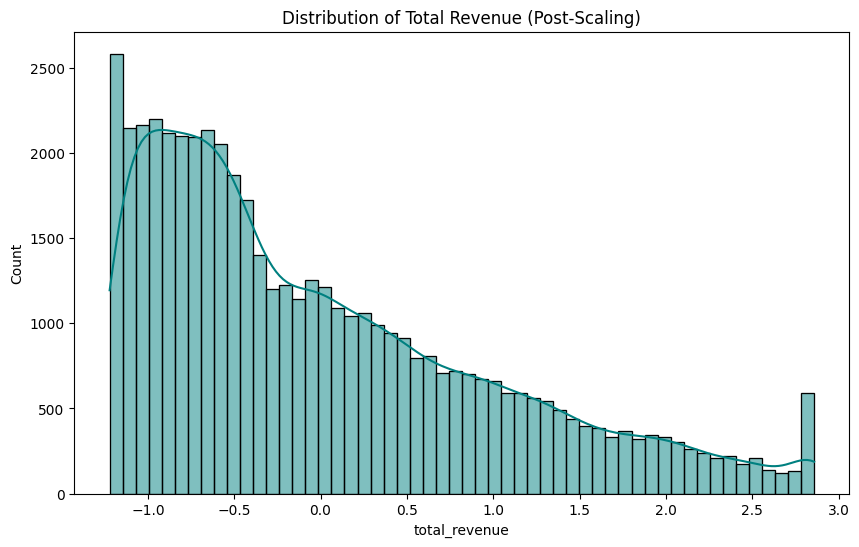

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the distribution of Revenue after treatment and scaling
plt.figure(figsize=(10, 6))
sns.histplot(df['total_revenue'], kde=True, color='teal')
plt.title('Distribution of Total Revenue (Post-Scaling)')
plt.show()

Key Findings:

The revenue distribution is right-skewed, showing that the majority of orders are for lower-priced items, while a small number of high-value transactions contribute significantly to overall sales.

2. Bivariate Analysis (Relationships)


This is where  find out what actually drives sales. For example, does a higher Rating lead to higher Total Revenue?

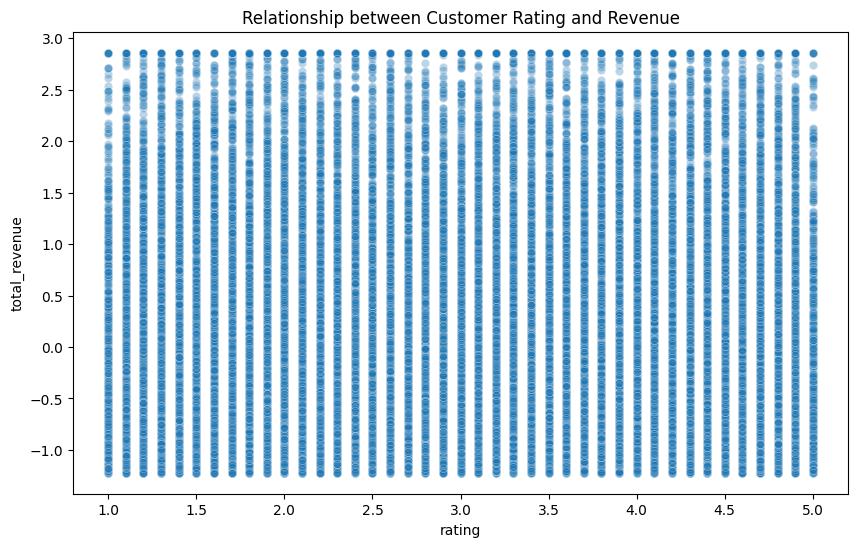

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='rating', y='total_revenue', alpha=0.3)
plt.title('Relationship between Customer Rating and Revenue')
plt.show()

Key Findings:

There is a dense cluster of transactions across all rating levels, suggesting that high revenue isn't exclusively tied to products with perfect 5-star ratings.

3. Correlation Heatmap


This is the "Golden Chart" of EDA. It shows which variables are mathematically linked to each other.

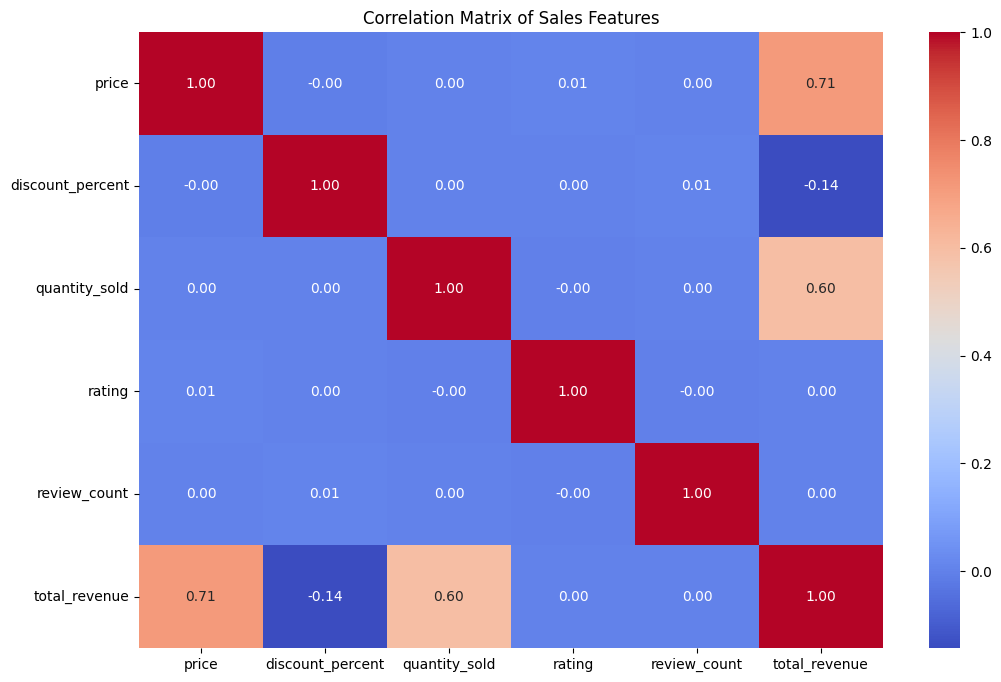

In [ ]:
plt.figure(figsize=(12, 8))
# Select only numerical columns for correlation
corr_matrix = df[['price', 'discount_percent', 'quantity_sold', 'rating', 'review_count', 'total_revenue']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Sales Features')
plt.show()

Key Findings:

There is a very strong positive correlation between price and discounted_price, and a significant relationship between quantity_sold and total_revenue, which is expected.

Interestingly, rating and review_count show a weak correlation with price, meaning customers are willing to buy and review products across all price points, not just expensive ones.